**EXP 6 - Implementation of Ensemble Techniques (Bagging, Boosting, Random Forest, Stacking) and Handling Class Imbalance (SMOTE)**

Name: Priyadharshini B

Roll no: 24BAD093

**SCENARIO** **1** -**(Bagging)**



Problem Statement:   Predict whether a patient has diabetes.

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


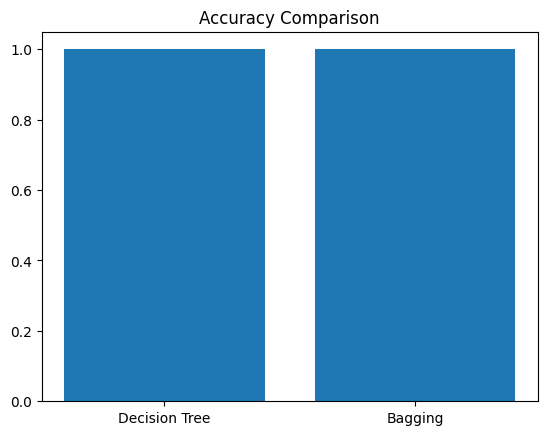

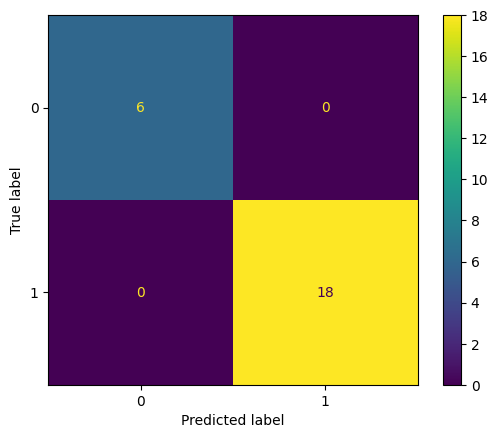

In [1]:
# Roll No: 24BAD093

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load Dataset
df = pd.read_csv("/content/diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Bar Graph
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.show()

**SCENARIO 2** – **(Boosting-AdaBoost, Gradient Boosting)**



Problem Statement: Predict whether a customer will churn.

Columns in dataset:
 Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


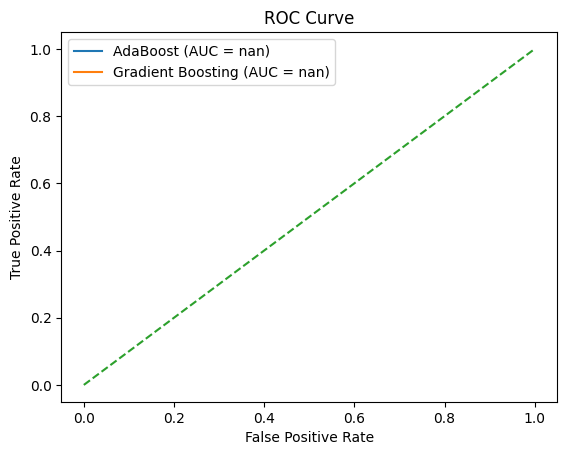

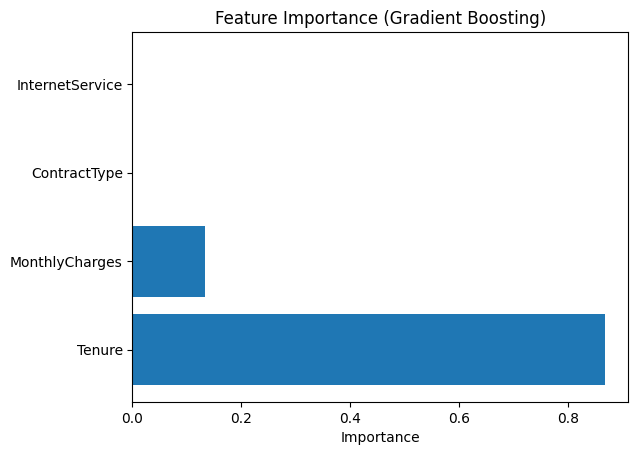

In [3]:
# Roll No: 24BAD093

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

df = pd.read_csv("/content/churn_boosting.csv")
df.columns = df.columns.str.strip()

print("Columns in dataset:\n", df.columns)

# STEP 3: HANDLE DATA ISSUES
# Convert TotalCharges to numeric (important for Telco dataset)
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Drop missing values
df = df.dropna()

# STEP 4: ENCODE CATEGORICAL DATA
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# DEFINE TARGET VARIABLE
# Automatically detect target column safely
target_column = None

for col in df.columns:
    if col.lower() == "churn":
        target_column = col

if target_column is None:
    raise Exception("'Churn' column not found. Check dataset column names!")

X = df.drop(target_column, axis=1)
y = df[target_column]


#  TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TRAIN MODELS

ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()

ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

# ROC CURVE

y_pred_ada = ada.predict_proba(X_test)[:, 1]
y_pred_gb = gb.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, y_pred_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_gb)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr1, tpr1, label=f"AdaBoost (AUC = {auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"Gradient Boosting (AUC = {auc2:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

importances = gb.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

**SCENARIO 3** – **Random Forest**



Problem Statement:  Predict whether a person earns >50K salary.

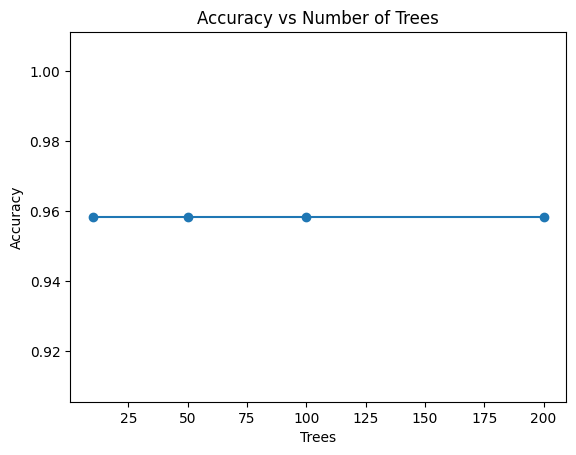

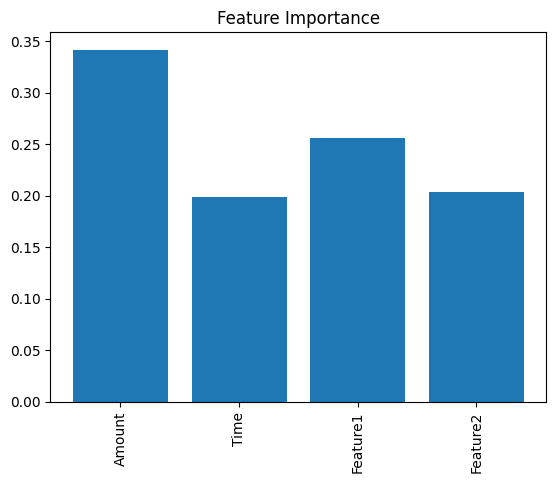

In [13]:
# Roll No: 24BAD093

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("/content/fraud_smote.csv")

# Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Tune Trees
trees = [10, 50, 100, 200]
accuracy = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    accuracy.append(accuracy_score(y_test, pred))

# Graph
plt.plot(trees, accuracy, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

**SCENARIO 4** – **Stacking**



Problem Statement:  Predict heart disease presence.

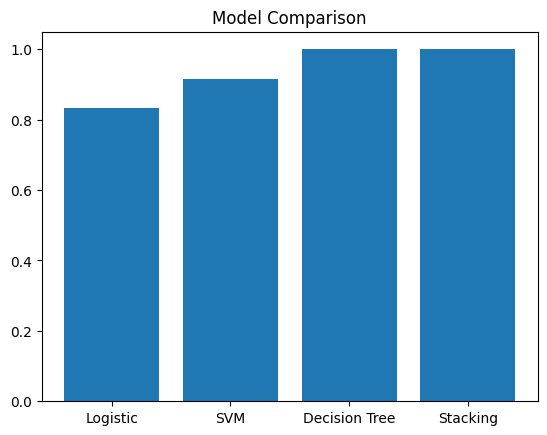

In [10]:
# Roll No: 24BAD093

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("/content/heart_stacking.csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Base Models
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

# Stacking
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

# Compare
models = {
    "Logistic": estimators[0][1],
    "SVM": estimators[1][1],
    "Decision Tree": estimators[2][1],
    "Stacking": stack
}

scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

# Bar Chart
plt.bar(models.keys(), scores)
plt.title("Model Comparison")
plt.show()

**SCENARIO 5** – **SMOTE**



Problem Statement:  Detect fraudulent transactions.

Before SMOTE:
 Income
0    80
1    40
Name: count, dtype: int64
After SMOTE:
 Income
0    80
1    80
Name: count, dtype: int64


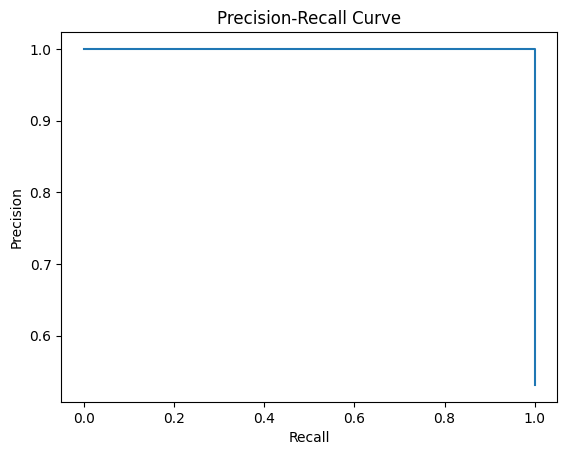

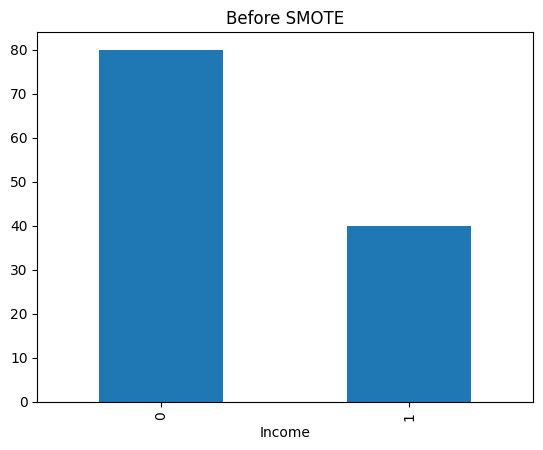

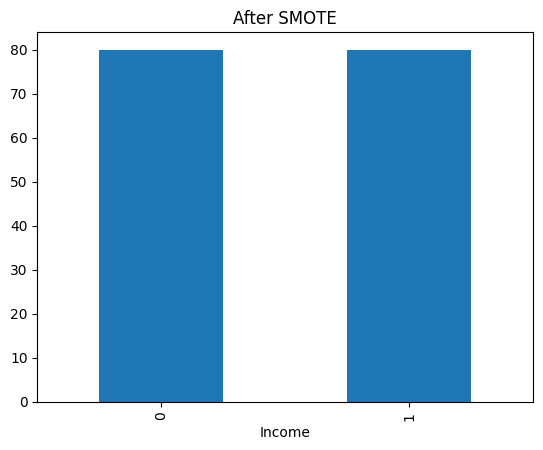

In [9]:
# Roll No: 24BAD093

import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

# Load Dataset
df = pd.read_csv("/content/income_random_forest.csv")

X = df.drop("Income", axis=1)
y = df["Income"]

# Before SMOTE
print("Before SMOTE:\n", y.value_counts())

# Apply SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

# After SMOTE
print("After SMOTE:\n", y_res.value_counts())

# Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

# Model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_scores = rf.predict_proba(X_test)[:,1]

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Class Distribution Plot
pd.Series(y).value_counts().plot(kind='bar', title="Before SMOTE")
plt.show()

pd.Series(y_res).value_counts().plot(kind='bar', title="After SMOTE")
plt.show()